# Notebook Objectives

In this notebooks, we'll go through the main behavioral analysis results.

Results include:
* ?
* ?

---
# Setup


In [1]:
# @title Imports
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, permutation_test_score, cross_validate

import statsmodels.api as sm
from statsmodels.formula.api import glm
from scipy.optimize import curve_fit

from popy.io_tools import load_behavior, load_simulation, load_behavior_yuri
from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from behav_analysis_tools import *
from popy.config import COLORS

# fontsize 12
plt.rcParams.update({'font.size': 8})


In [32]:
# @title Data retrieval and loading
def get_data_custom():
    behav = load_behavior()
    behav = drop_time_fields(behav)

    behav_yuri = load_behavior_yuri()
    simulation_ka = load_simulation(monkey='ka')
    simulation_ka.drop(columns=['stay_value'], inplace=True)
    simulation_po = load_simulation(monkey='po')
    simulation_po.drop(columns=['stay_value'], inplace=True)

    behav = pd.concat([behav, behav_yuri, simulation_ka, simulation_po], ignore_index=True)

    behav = add_switch_info(behav, add_trials_since_switch=True)

    #behav = add_history_of_feedback(behav, one_column=True, num_trials=5)
    behav = add_history_of_feedback(behav, one_column=False, num_trials=8, add_history_of_targets=False)
    #behav = add_phase_info(behav, exploration_limit=6, transition_limit=0)

    behav = behav.dropna()

    return behav

---
# Get data

In [49]:
behav = get_data_custom()
#behav.drop(columns=['block_id', 'best_target', 'trials_since_switch'], inplace=True)
print(behav.head())

   monkey session  trial_id  block_id  best_target  target  feedback  switch   
8      ka  010720         8         0            2     2.0       1.0     0.0  \
9      ka  010720         9         0            2     2.0       1.0     0.0   
10     ka  010720        10         0            2     2.0       1.0     0.0   
11     ka  010720        11         0            2     2.0       1.0     0.0   
12     ka  010720        12         0            2     2.0       1.0     0.0   

    trials_since_switch  R_1  R_2  R_3  R_4  R_5  R_6  R_7  R_8  
8                     2  1.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  
9                     3  1.0  1.0  1.0  0.0  1.0  0.0  1.0  0.0  
10                    4  1.0  1.0  1.0  1.0  0.0  1.0  0.0  1.0  
11                    5  1.0  1.0  1.0  1.0  1.0  0.0  1.0  0.0  
12                    6  1.0  1.0  1.0  1.0  1.0  1.0  0.0  1.0  


Fitting HMM-GLM model...
Iteration 0, Log-likelihood: 0.00
Converged after 2 iterations


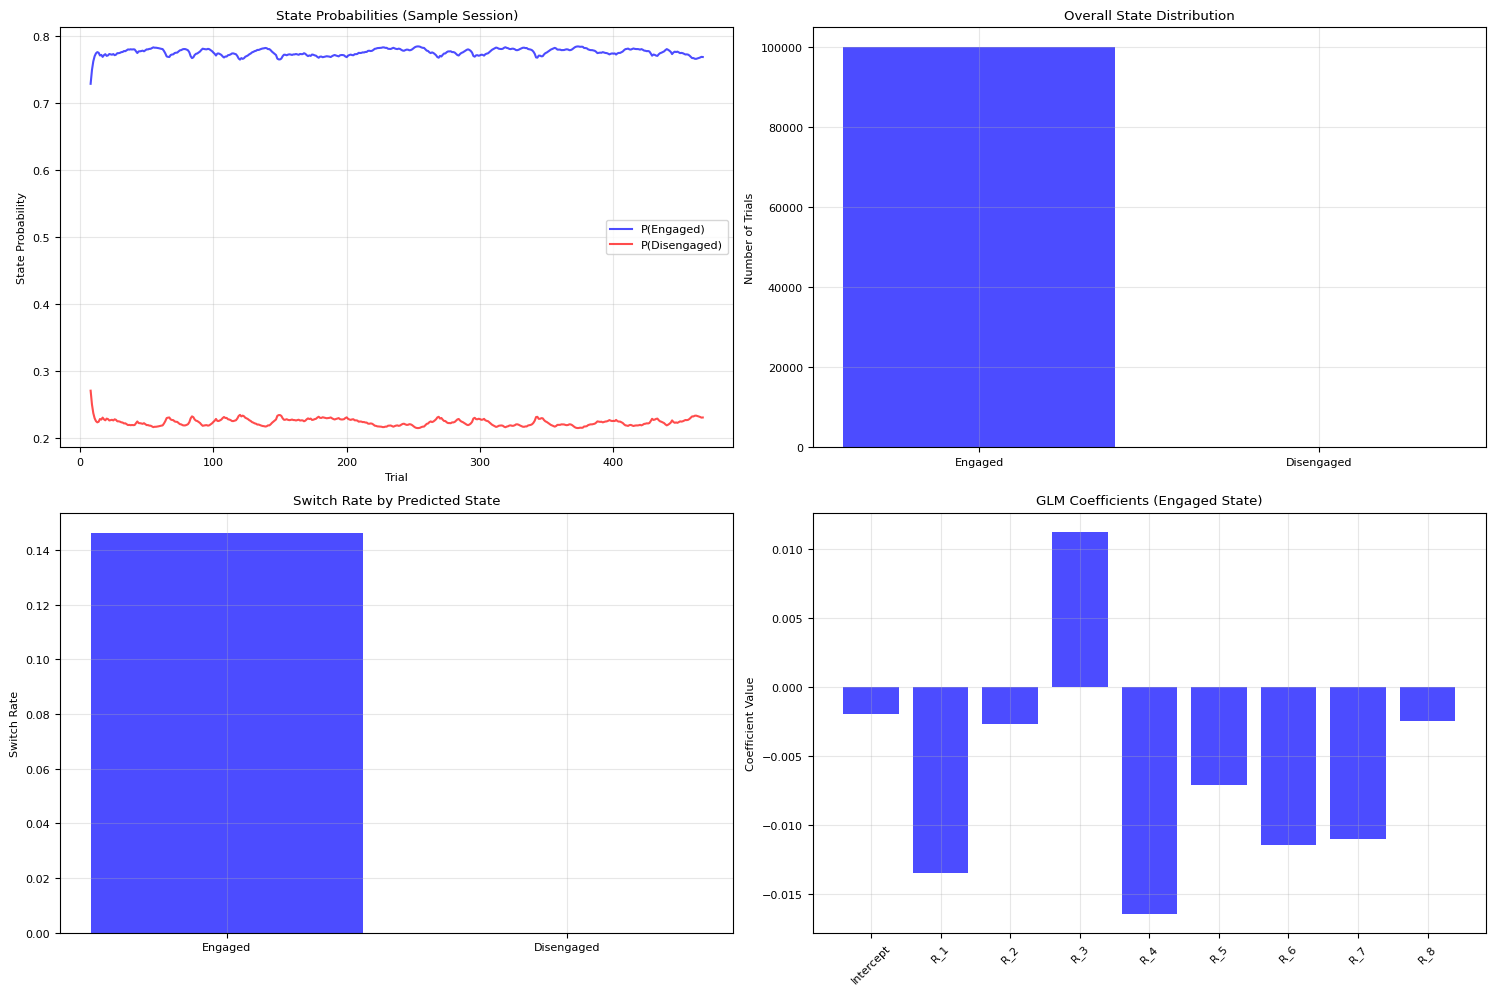


MODEL SUMMARY
Total trials: 99989
Engaged trials: 99989 (100.0%)
Disengaged trials: 0 (0.0%)

Transition Matrix:
P(Engaged -> Engaged): 0.906
P(Engaged -> Disengaged): 0.094
P(Disengaged -> Engaged): 0.313
P(Disengaged -> Disengaged): 0.687

GLM Coefficients (Engaged State):
Intercept: -0.0020
R_1: -0.0135
R_2: -0.0027
R_3: 0.0113
R_4: -0.0164
R_5: -0.0071
R_6: -0.0115
R_7: -0.0110
R_8: -0.0024


In [50]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import expit  # sigmoid function
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class HMM_GLM:
    """
    Hidden Markov Model with GLM emission probabilities for monkey behavioral states.
    
    State 0: Engaged - switching behavior predicted by reward history
    State 1: Disengaged - random switching behavior
    """
    
    def __init__(self, n_states=2, n_history=8):
        self.n_states = n_states
        self.n_history = n_history
        
        # Initialize parameters
        self.transition_matrix = np.array([[0.9, 0.1],   # P(stay engaged), P(engaged->disengaged)
                                          [0.3, 0.7]])   # P(disengaged->engaged), P(stay disengaged)
        
        # GLM parameters for each state
        # State 0 (engaged): small random coefficients for reward history predicting switching
        # State 1 (disengaged): flat coefficients (no prediction)
        self.glm_params = {
            0: np.random.normal(0, 0.01, n_history + 1),  # Smaller initial values
            1: np.array([0.0] * (n_history + 1))  # flat coefficients for disengaged state
        }
        
        # Initial state probabilities
        self.initial_probs = np.array([0.7, 0.3])  # Start more likely engaged
        
    def prepare_features(self, behav_data):
        """Prepare feature matrix from behavioral data"""
        # Extract reward history features (R_1 to R_8)
        reward_cols = [f'R_{i}' for i in range(1, self.n_history + 1)]
        X = behav_data[reward_cols].values
        
        # Add intercept term
        X = np.column_stack([np.ones(len(X)), X])
        
        # Target variable (switch behavior)
        y = behav_data['switch'].values
        
        return X, y
    
    def emission_probability(self, y, X, state):
        """Calculate emission probability P(y|X, state)"""
        # Linear combination of features
        linear_pred = np.dot(X, self.glm_params[state])
        
        # Clip linear predictions to avoid overflow
        linear_pred = np.clip(linear_pred, -10, 10)
        
        # Sigmoid transformation to get probability
        prob_switch = expit(linear_pred)
        
        # Ensure prob_switch is in valid range
        prob_switch = np.clip(prob_switch, 1e-6, 1 - 1e-6)
        
        # Bernoulli likelihood
        prob = y * prob_switch + (1 - y) * (1 - prob_switch)
        
        # Final clipping to avoid numerical issues
        prob = np.clip(prob, 1e-10, 1 - 1e-10)
        
        return prob
    
    def forward_backward(self, X, y):
        """Forward-backward algorithm for HMM"""
        T = len(y)
        
        # Forward pass
        alpha = np.zeros((T, self.n_states))
        
        # Initialize
        for s in range(self.n_states):
            emission_prob = self.emission_probability(y[0], X[0], s)
            alpha[0, s] = self.initial_probs[s] * emission_prob
        
        # Normalize to avoid underflow
        alpha[0, :] = alpha[0, :] / (np.sum(alpha[0, :]) + 1e-10)
        
        # Forward recursion
        for t in range(1, T):
            for s in range(self.n_states):
                alpha[t, s] = self.emission_probability(y[t], X[t], s) * \
                             np.sum(alpha[t-1, :] * self.transition_matrix[:, s])
            
            # Normalize to prevent underflow
            row_sum = np.sum(alpha[t, :])
            if row_sum > 0:
                alpha[t, :] = alpha[t, :] / row_sum
        
        # Backward pass
        beta = np.zeros((T, self.n_states))
        beta[T-1, :] = 1.0
        
        for t in range(T-2, -1, -1):
            for s in range(self.n_states):
                emission_probs = np.array([self.emission_probability(y[t+1], X[t+1], j) 
                                         for j in range(self.n_states)])
                beta[t, s] = np.sum(self.transition_matrix[s, :] * emission_probs * beta[t+1, :])
            
            # Normalize to prevent underflow
            row_sum = np.sum(beta[t, :])
            if row_sum > 0:
                beta[t, :] = beta[t, :] / row_sum
        
        # Calculate gamma (state probabilities)
        gamma = alpha * beta
        gamma_sum = np.sum(gamma, axis=1, keepdims=True)
        gamma_sum = np.where(gamma_sum == 0, 1e-10, gamma_sum)  # Avoid division by zero
        gamma = gamma / gamma_sum
        
        # Calculate xi (transition probabilities)
        xi = np.zeros((T-1, self.n_states, self.n_states))
        for t in range(T-1):
            for i in range(self.n_states):
                for j in range(self.n_states):
                    xi[t, i, j] = (alpha[t, i] * self.transition_matrix[i, j] * 
                                  self.emission_probability(y[t+1], X[t+1], j) * beta[t+1, j])
            
            # Normalize xi
            xi_sum = np.sum(xi[t])
            if xi_sum > 0:
                xi[t] = xi[t] / xi_sum
            else:
                # If sum is 0, set to uniform distribution
                xi[t] = np.ones((self.n_states, self.n_states)) / (self.n_states * self.n_states)
        
        return alpha, beta, gamma, xi
    
    def m_step(self, X, y, gamma, xi):
        """M-step: Update parameters"""
        T = len(y)
        
        # Update transition matrix
        for i in range(self.n_states):
            for j in range(self.n_states):
                numerator = np.sum(xi[:, i, j])
                denominator = np.sum(gamma[:-1, i])
                if denominator > 1e-10:
                    self.transition_matrix[i, j] = numerator / denominator
                else:
                    # Keep current value if denominator is too small
                    pass
        
        # Ensure transition matrix rows sum to 1
        for i in range(self.n_states):
            row_sum = np.sum(self.transition_matrix[i, :])
            if row_sum > 0:
                self.transition_matrix[i, :] = self.transition_matrix[i, :] / row_sum
        
        # Update initial probabilities
        self.initial_probs = gamma[0, :]
        
        # Update GLM parameters for engaged state (state 0)
        # Use weighted logistic regression
        weights = gamma[:, 0]
        if np.sum(weights) > 0:
            self.glm_params[0] = self._weighted_logistic_regression(X, y, weights)
        
        # Keep disengaged state (state 1) parameters at zero (random behavior)
        # self.glm_params[1] remains unchanged (all zeros)
    
    def _weighted_logistic_regression(self, X, y, weights):
        """Weighted logistic regression for GLM parameters"""
        def neg_log_likelihood(params):
            linear_pred = np.dot(X, params)
            prob = expit(linear_pred)
            prob = np.clip(prob, 1e-10, 1 - 1e-10)
            ll = weights * (y * np.log(prob) + (1 - y) * np.log(1 - prob))
            return -np.sum(ll)
        
        # Initialize with current parameters
        init_params = self.glm_params[0].copy()
        
        # Optimize
        result = minimize(neg_log_likelihood, init_params, method='BFGS')
        
        return result.x if result.success else init_params
    
    def fit(self, behav_data, max_iter=100, tol=1e-6):
        """Fit the HMM-GLM model using EM algorithm"""
        # Group by monkey and session to handle non-consecutive sessions
        sessions = []
        for (monkey, session), group in behav_data.groupby(['monkey', 'session']):
            sessions.append(group.sort_values('trial_id').reset_index(drop=True))
        
        prev_ll = -np.inf
        
        for iteration in range(max_iter):
            total_ll = 0
            
            # E-step and M-step for each session
            all_gamma = []
            all_xi = []
            all_X = []
            all_y = []
            
            for session_data in sessions:
                if len(session_data) < 2:  # Skip sessions with too few trials
                    continue
                    
                X, y = self.prepare_features(session_data)
                alpha, beta, gamma, xi = self.forward_backward(X, y)
                
                # Calculate log-likelihood for this session
                # Use the unnormalized forward probabilities for likelihood calculation
                session_ll = np.sum(np.log(np.sum(alpha[-1, :]) + 1e-10))
                total_ll += session_ll
                
                all_gamma.append(gamma)
                all_xi.append(xi)
                all_X.append(X)
                all_y.append(y)
            
            # M-step: combine data from all sessions
            if all_gamma:
                combined_gamma = np.vstack(all_gamma)
                combined_xi = np.vstack(all_xi)
                combined_X = np.vstack(all_X)
                combined_y = np.hstack(all_y)
                
                self.m_step(combined_X, combined_y, combined_gamma, combined_xi)
            
            # Check convergence
            if abs(total_ll - prev_ll) < tol:
                print(f"Converged after {iteration + 1} iterations")
                break
            
            prev_ll = total_ll
            
            if iteration % 10 == 0:
                print(f"Iteration {iteration}, Log-likelihood: {total_ll:.2f}")
        
        return self
    
    def predict_states(self, behav_data):
        """Predict latent states for each trial"""
        results = []
        
        for (monkey, session), group in behav_data.groupby(['monkey', 'session']):
            session_data = group.sort_values('trial_id').reset_index(drop=True)
            
            if len(session_data) < 2:
                continue
            
            X, y = self.prepare_features(session_data)
            _, _, gamma, _ = self.forward_backward(X, y)
            
            # Most likely state for each trial
            predicted_states = np.argmax(gamma, axis=1)
            state_probs = gamma
            
            # Add results to session data
            session_results = session_data.copy()
            session_results['predicted_state'] = predicted_states
            session_results['prob_engaged'] = state_probs[:, 0]
            session_results['prob_disengaged'] = state_probs[:, 1]
            
            results.append(session_results)
        
        return pd.concat(results, ignore_index=True)
    
    def plot_results(self, results_df):
        """Plot model results"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: State probabilities over trials
        sample_session = results_df.groupby(['monkey', 'session']).first().reset_index().iloc[0]
        session_data = results_df[
            (results_df['monkey'] == sample_session['monkey']) & 
            (results_df['session'] == sample_session['session'])
        ]
        
        axes[0, 0].plot(session_data['trial_id'], session_data['prob_engaged'], 
                       label='P(Engaged)', color='blue', alpha=0.7)
        axes[0, 0].plot(session_data['trial_id'], session_data['prob_disengaged'], 
                       label='P(Disengaged)', color='red', alpha=0.7)
        axes[0, 0].set_xlabel('Trial')
        axes[0, 0].set_ylabel('State Probability')
        axes[0, 0].set_title('State Probabilities (Sample Session)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: State distribution
        state_counts = results_df['predicted_state'].value_counts()
        axes[0, 1].bar(['Engaged', 'Disengaged'], 
                      [state_counts.get(0, 0), state_counts.get(1, 0)],
                      color=['blue', 'red'], alpha=0.7)
        axes[0, 1].set_ylabel('Number of Trials')
        axes[0, 1].set_title('Overall State Distribution')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: Switching behavior by state
        switch_by_state = results_df.groupby('predicted_state')['switch'].mean()
        axes[1, 0].bar(['Engaged', 'Disengaged'], 
                      [switch_by_state.get(0, 0), switch_by_state.get(1, 0)],
                      color=['blue', 'red'], alpha=0.7)
        axes[1, 0].set_ylabel('Switch Rate')
        axes[1, 0].set_title('Switch Rate by Predicted State')
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: GLM coefficients for engaged state
        coef_names = ['Intercept'] + [f'R_{i}' for i in range(1, self.n_history + 1)]
        axes[1, 1].bar(range(len(self.glm_params[0])), self.glm_params[0], 
                       color='blue', alpha=0.7)
        axes[1, 1].set_xticks(range(len(coef_names)))
        axes[1, 1].set_xticklabels(coef_names, rotation=45)
        axes[1, 1].set_ylabel('Coefficient Value')
        axes[1, 1].set_title('GLM Coefficients (Engaged State)')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print model summary
        print("\n" + "="*50)
        print("MODEL SUMMARY")
        print("="*50)
        print(f"Total trials: {len(results_df)}")
        print(f"Engaged trials: {np.sum(results_df['predicted_state'] == 0)} "
              f"({np.mean(results_df['predicted_state'] == 0)*100:.1f}%)")
        print(f"Disengaged trials: {np.sum(results_df['predicted_state'] == 1)} "
              f"({np.mean(results_df['predicted_state'] == 1)*100:.1f}%)")
        
        print(f"\nTransition Matrix:")
        print(f"P(Engaged -> Engaged): {self.transition_matrix[0,0]:.3f}")
        print(f"P(Engaged -> Disengaged): {self.transition_matrix[0,1]:.3f}")
        print(f"P(Disengaged -> Engaged): {self.transition_matrix[1,0]:.3f}")
        print(f"P(Disengaged -> Disengaged): {self.transition_matrix[1,1]:.3f}")
        
        print(f"\nGLM Coefficients (Engaged State):")
        for i, coef in enumerate(self.glm_params[0]):
            name = 'Intercept' if i == 0 else f'R_{i}'
            print(f"{name}: {coef:.4f}")

# Example usage:
def analyze_monkey_behavior(behav):
    """
    Main function to analyze monkey behavioral data
    
    Parameters:
    behav: pandas DataFrame with columns:
        - monkey, session, trial_id, target, feedback, switch
        - R_1, R_2, ..., R_8 (reward history)
    """
    
    print("Fitting HMM-GLM model...")
    
    # Initialize and fit the model
    model = HMM_GLM(n_states=2, n_history=8)
    model.fit(behav, max_iter=50)
    
    # Predict states
    results = model.predict_states(behav)
    
    # Plot results
    model.plot_results(results)
    
    return model, results

# To use with your data:
model, results = analyze_monkey_behavior(behav)
# 
# The results DataFrame will contain:
# - All original columns from behav
# - predicted_state: 0 (engaged) or 1 (disengaged)
# - prob_engaged: probability of being in engaged state
# - prob_disengaged: probability of being in disengaged state

In [51]:
results

,monkey,session,trial_id,block_id,best_target,target,feedback,switch,trials_since_switch,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,predicted_state,prob_engaged,prob_disengaged
0,ka,010720,8,0,2,2.0,1.0,0.0,2,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0,0.729167,0.270833
1,ka,010720,9,0,2,2.0,1.0,0.0,3,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0,0.749851,0.250149
2,ka,010720,10,0,2,2.0,1.0,0.0,4,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0,0.762750,0.237250
3,ka,010720,11,0,2,2.0,1.0,0.0,5,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0,0.770409,0.229591
4,ka,010720,12,0,2,2.0,1.0,0.0,6,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0,0.774657,0.225343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99984,yu_sham,71,535,12,3,3.0,1.0,0.0,3,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0,0.776215,0.223785
99985,yu_sham,71,536,12,3,3.0,1.0,0.0,4,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0,0.776866,0.223134
99986,yu_sham,71,537,12,3,3.0,1.0,0.0,5,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0.777494,0.222506
99987,yu_sham,71,538,12,3,3.0,1.0,0.0,6,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0.777832,0.222168


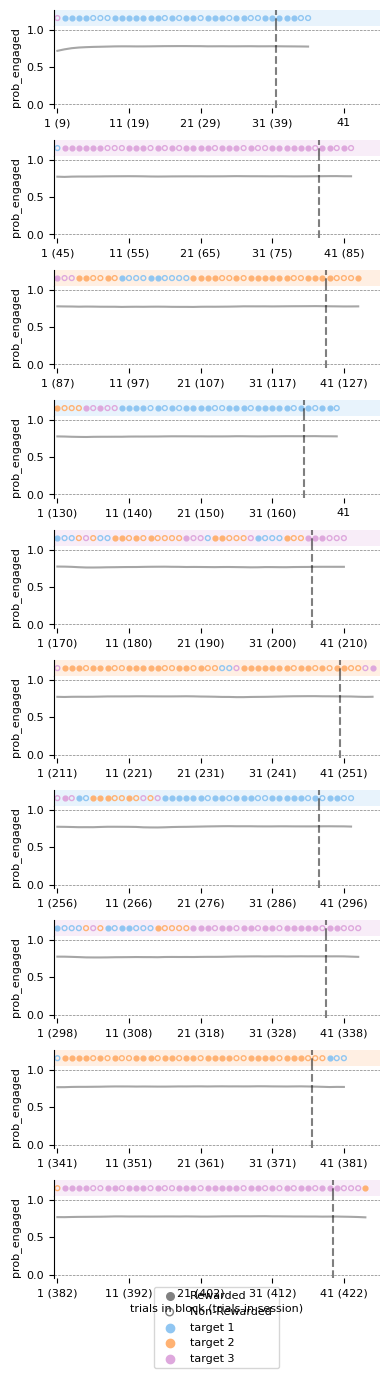

In [52]:
# plot example session
behav_example = results[
    (results['monkey'] == 'ka') & 
    (results['session'] == '210322')
]

# target selection
#savedir = os.path.join('figs', 'example_session_compact.svg')
show_target_selection_compact(behav_example, 
                              format='poster',
                              background_values=['prob_engaged'],   # here we tell what variable to use as background - value in this case
                              title=None, #f'monkey: {monkey}, session: {session}', 
                              show=True, 
                              savedir=None)